In [3]:
from pathlib import Path
import pandas as pd
from IPython.display import display
import sys
from pathlib import Path

# Path to the parent folder (where util.py is)
parent_path = Path().resolve().parent  # notebook's parent directory
sys.path.append(str(parent_path))
import util

# Load data
df = util.load_data()
display(df.head())

,jahr,geschlecht,altersklasse,disziplin,leistung,wind,name,geburtsjahr,verein,datum,ort
0,2017,W,Frauen,100 m,10.95,"+1,3",Gina Lueckenkemper,1996,LG Olympia Dortmund,05.08.,London/GBR
1,2017,W,Frauen,100 m,11.06,"+1,8",Rebekka Haase,1993,LV 90 Erzgebirge,25.05.,Zeulenroda
2,2017,W,Frauen,100 m,11.14,"-0,2",Lisa Mayer,1996,Sprintteam Wetzlar,27.08.,Berlin
3,2017,W,Frauen,100 m,11.24,"+0,3",Tatjana Pinto,1992,LC Paderborn,15.07.,Ninove/BEL
4,2017,W,Frauen,100 m,11.25,"+1,9",Sina Mayer,1995,LAZ Zweibruecken,11.06.,Regensburg


In [4]:
# Choosing Disziplin / Gender 

disziplin = "5000 m"
gender = "M"
altersklasse = "Maenner"
filtered_data = df[(df["disziplin"] == disziplin) & (df["geschlecht"] == gender) & (df["altersklasse"] == altersklasse)]
filtered_data.head()


,jahr,geschlecht,altersklasse,disziplin,leistung,wind,name,geburtsjahr,verein,datum,ort
4669,2005,M,Maenner,5000 m,809.37,NaN,Jan Fitschen,1977,TV Wattenscheid 01,14.06.,Luzern/SUI
4670,2005,M,Maenner,5000 m,813.26,NaN,Arne Gabius,1981,LAV asics Tuebingen,23.07.,Heusden/BEL
4671,2005,M,Maenner,5000 m,821.41,NaN,Filmon Ghirmai,1979,LAV asics Tuebingen,18.05.,Koblenz
4672,2005,M,Maenner,5000 m,839.7,NaN,Carlo Schuff,1980,Gerolsteiner LGV,18.05.,Koblenz
4673,2005,M,Maenner,5000 m,839.74,NaN,Lars Haferkamp,1979,TV Refrath,22.06.,Papendal/NED


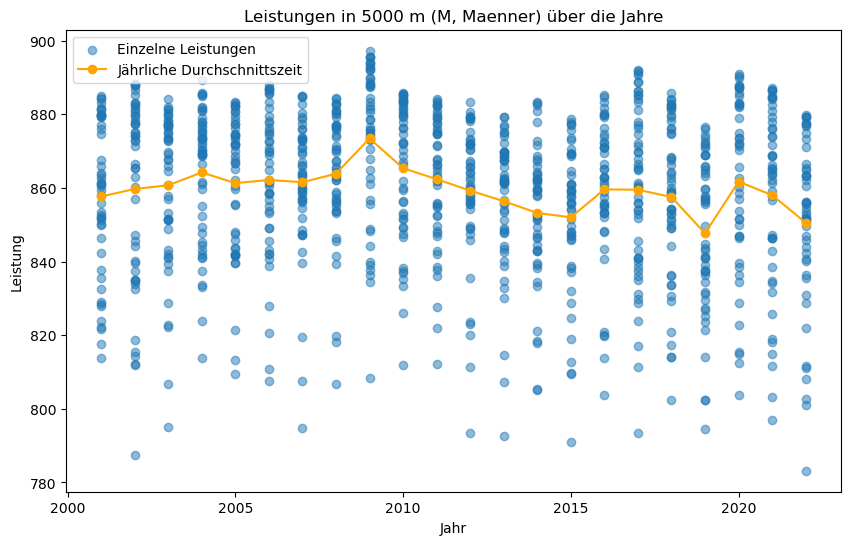

In [5]:
import matplotlib.pyplot as plt
# Plot all data points with times on y-axis and year on x-axis + Mean per year line
mean_per_year = filtered_data.groupby("jahr")["leistung"].mean()
plt.figure(figsize=(10, 6))
plt.scatter(filtered_data["jahr"], filtered_data["leistung"], alpha=0.5, label="Einzelne Leistungen")
plt.plot(mean_per_year.index, mean_per_year.values, color='orange', marker='o', label='Jährliche Durchschnittszeit')
plt.title(f'Leistungen in {disziplin} ({gender}, {altersklasse}) über die Jahre')
plt.xlabel('Jahr')              
plt.ylabel('Leistung')
plt.legend()
plt.show()

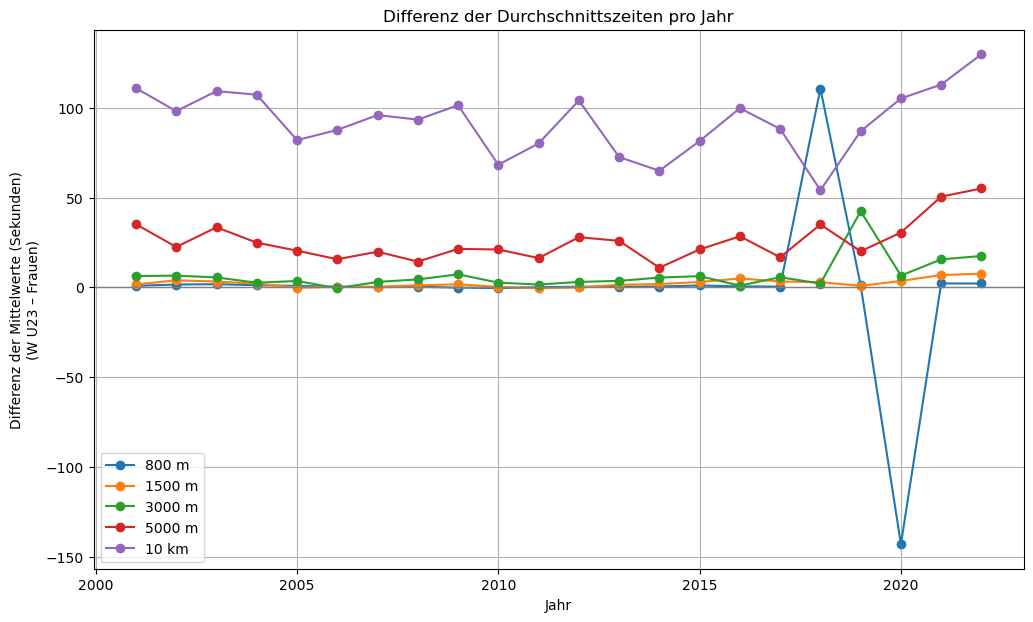

In [6]:
plt.figure(figsize=(12, 7))

disziplinen = ["800 m","1500 m", "3000 m", "5000 m", "10 km"]

for disziplin in disziplinen:
    # Mittelwerte speichern
    means = {}

    for altersklasse in ["U23", "Frauen"]:
        subset = df[
            (df["disziplin"] == disziplin) &
            (df["geschlecht"] == "W") &
            (df["altersklasse"] == altersklasse)
        ].copy()
        # Mittelwert pro Jahr
        means[altersklasse] = subset.groupby("jahr")["leistung"].mean()
    # gemeinsame Jahre
    common_years = means["U23"].index.intersection(means["Frauen"].index)
    # einfache Differenz der Mittelwerte
    difference = means["U23"].loc[common_years] - means["Frauen"].loc[common_years]
    
    # Plotten
    plt.plot(
        difference.index,
        difference.values,
        marker="o",
        label=disziplin
    )

plt.axhline(0, color="gray", linewidth=1)  # Hilfslinie
plt.xlabel("Jahr")
plt.ylabel("Differenz der Mittelwerte (Sekunden)\n(W U23 – Frauen)")
plt.title("Differenz der Durchschnittszeiten pro Jahr")
plt.legend()
plt.grid(True)
plt.show()


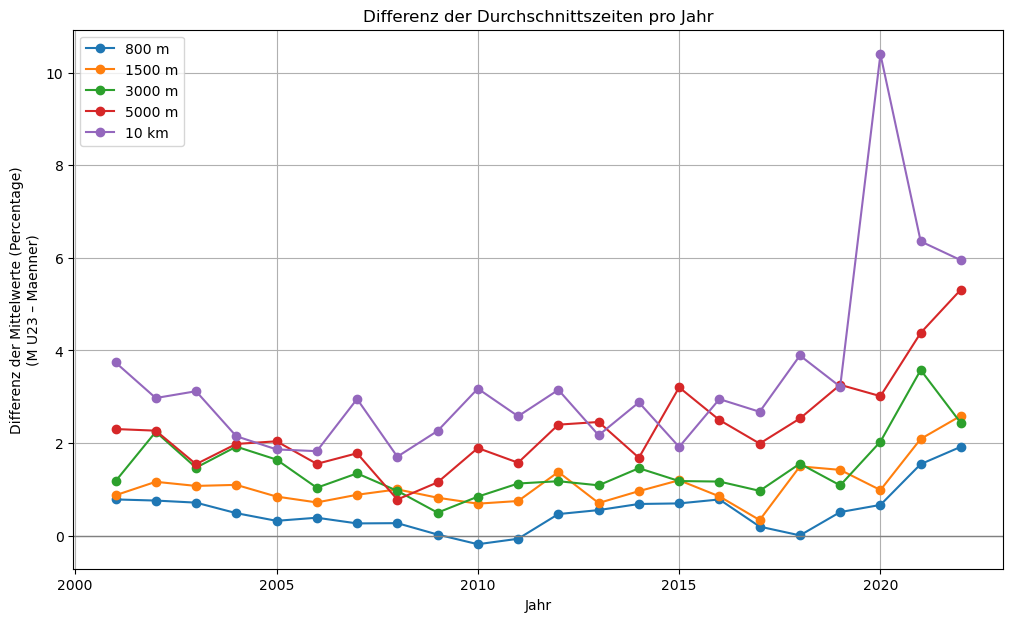

In [7]:
plt.figure(figsize=(12, 7))

# Seconds does not allow for comparison between distances, its clear there is more difference in longer races7
# Changing to percentage difference

disziplinen = ["800 m","1500 m", "3000 m", "5000 m", "10 km"]

for disziplin in disziplinen:
    # Mittelwerte speichern
    means = {}

    for altersklasse in ["U23", "Maenner"]:
        subset = df[
            (df["disziplin"] == disziplin) &
            (df["geschlecht"] == "M") &
            (df["altersklasse"] == altersklasse)
        ].copy()
        # Mittelwert pro Jahr
        means[altersklasse] = subset.groupby("jahr")["leistung"].mean()
    # gemeinsame Jahre
    common_years = means["U23"].index.intersection(means["Maenner"].index)
    # einfache Differenz der Mittelwerte
    difference = (means["U23"].loc[common_years] - means["Maenner"].loc[common_years]) \
                / means["Maenner"].loc[common_years] * 100
    
    # Plotten
    plt.plot(
        difference.index,
        difference.values,
        marker="o",
        label=disziplin
    )

plt.axhline(0, color="gray", linewidth=1)  # Hilfslinie
plt.xlabel("Jahr")
plt.ylabel("Differenz der Mittelwerte (Percentage)\n(M U23 – Maenner)")
plt.title("Differenz der Durchschnittszeiten pro Jahr")
plt.legend()
plt.grid(True)
plt.show()


In [8]:
# Mean Difference for M U23 and Maenner and W U23 and Frauen summed over all years for every disziplin
disziplinen = ["800 m","1500 m", "3000 m", "5000 m", "10 km"]
gender = ["W", "M"]
for gender in gender:
    if gender == "W":
        ak = "Frauen"
    else:
        ak = "Maenner"
    print(ak)
    for disziplin in disziplinen:
        # Mittelwerte speichern
        means = {}
        for altersklasse in ["U23", ak]:
            subset = df[
                (df["disziplin"] == disziplin) &
                (df["geschlecht"] == gender) &
                (df["altersklasse"] == altersklasse)
            ].copy()
            means[altersklasse] = subset.groupby("jahr")["leistung"].mean()
        # gemeinsame Jahre
        common_years = means["U23"].index.intersection(means[ak].index)
        common_years = common_years[common_years != 2020]
        # einfache Differenz der Mittelwerte
        difference = (means["U23"].loc[common_years] - means[ak].loc[common_years]) \
                    / means[ak].loc[common_years] * 100
        avg_difference = difference.mean()
        print(f"Average difference in {disziplin} for {gender} and U23: {avg_difference:.2f}%")


Frauen
Average difference in 800 m for W and U23: 2.46%
Average difference in 1500 m for W and U23: 0.85%
Average difference in 3000 m for W and U23: 1.22%
Average difference in 5000 m for W and U23: 2.54%
Average difference in 10 km for W and U23: 4.37%
Maenner
Average difference in 800 m for M and U23: 0.53%
Average difference in 1500 m for M and U23: 1.09%
Average difference in 3000 m for M and U23: 1.43%
Average difference in 5000 m for M and U23: 2.31%
Average difference in 10 km for M and U23: 3.02%


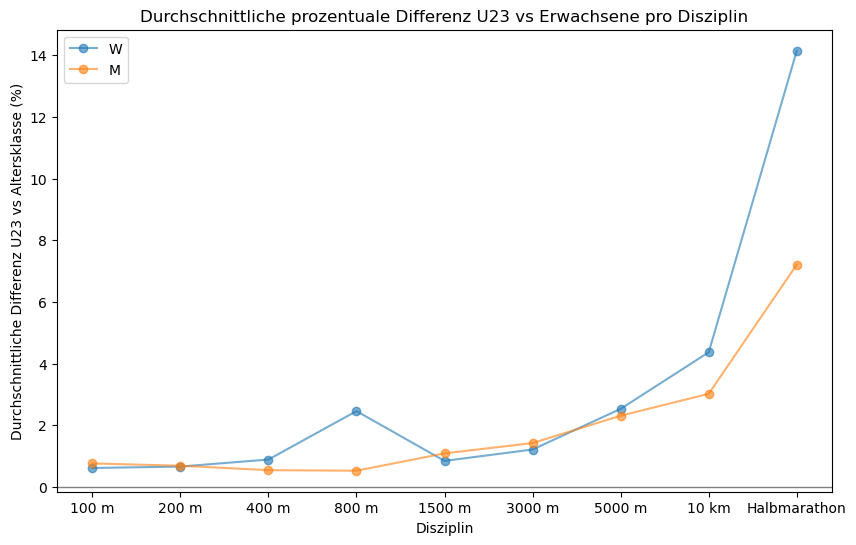

In [9]:
import matplotlib.pyplot as plt

disziplinen = ["100 m","200 m","400 m","800 m","1500 m", "3000 m", "5000 m", "10 km", "Halbmarathon"]
genders = ["W", "M"]

# Ergebnisse speichern
results = {"Disziplin": [], "Gender": [], "AvgDiffPercent": []}

for gender in genders:
    ak = "Frauen" if gender == "W" else "Maenner"
    
    for disziplin in disziplinen:
        means = {}
        for altersklasse in ["U23", ak]:
            subset = df[
                (df["disziplin"] == disziplin) &
                (df["geschlecht"] == gender) &
                (df["altersklasse"] == altersklasse)
            ].copy()
            means[altersklasse] = subset.groupby("jahr")["leistung"].mean()
        
        # Gemeinsame Jahre, 2020 ausschließen
        common_years = means["U23"].index.intersection(means[ak].index)
        common_years = common_years[common_years != 2020]
        
        # Prozentdifferenz berechnen
        difference = (means["U23"].loc[common_years] - means[ak].loc[common_years]) \
                     / means[ak].loc[common_years] * 100
        avg_difference = difference.mean()
        
        # Ergebnisse speichern
        results["Disziplin"].append(disziplin)
        results["Gender"].append(gender)
        results["AvgDiffPercent"].append(avg_difference)

# Plot
fig, ax = plt.subplots(figsize=(10,6))

for gender in genders:
    mask = [g == gender for g in results["Gender"]]
    x = [d for d, m in zip(results["Disziplin"], mask) if m]
    y = [v for v, m in zip(results["AvgDiffPercent"], mask) if m]
    ax.plot(x, y, marker="o", alpha=0.6, label=gender)

ax.set_xlabel("Disziplin")
ax.set_ylabel("Durchschnittliche Differenz U23 vs Altersklasse (%)")
ax.set_title("Durchschnittliche prozentuale Differenz U23 vs Erwachsene pro Disziplin")
ax.axhline(0, color="gray", linewidth=1)
ax.legend(["W", "M"])
plt.show()


In [16]:
import matplotlib.pyplot as plt
import pandas as pd

data_wa = pd.read_csv("C:\\Users\\Mattis\\OneDrive\\Kogni\\DataLiteracyProject\\Data-Literacy\\data_csv\\data_with_wa_scores.csv", sep=",")
#Drop al None entries in wa_score
data_wa = data_wa.dropna(subset=["wa_score"])

#get all data where wa score less than 50
data_wa_filtered = data_wa[data_wa["wa_score"] < 20]

#filter for only olympic distances
olympic_distances = olympic_disciplines = [
    # Lauf
    '100 m', '200 m', '400 m', '800 m', '1500 m', '5000 m', '10000 m', 'Marathon',
    '100 m Huerden', '110 m Hürden', '400 m Huerden', '3000 m Hindernis', 
    '20 km Gehen', '50 km Gehen',

    # Sprung/Wurf
    'Hochsprung', 'Stabhochsprung', 'Weitsprung', 'Dreisprung',
    'Kugelstoß', 'Diskuswurf', 'Hammerwurf', 'Speerwurf',

    # Mehrkampf
    'Siebenkampf', 'Zehnkampf'
]

data_wa["altersklasse"] = data_wa["altersklasse"].replace({"Maenner": "Erwachsene", "Frauen": "Erwachsene"})

data_wa = data_wa[(data_wa["disziplin"].isin(olympic_distances)) &
                           (data_wa["altersklasse"] == "Erwachsene")]

data_wa = data_wa[(data_wa["wa_score"] > 25) & (data_wa["wa_score"] < 1380)]

# AK Maenner and Women to adult
data_wa.head()

,jahr,geschlecht,altersklasse,disziplin,leistung,wind,name,geburtsjahr,verein,datum,ort,wa_score
0,2017,W,Erwachsene,100 m,10.95,"+1,3",Gina Lueckenkemper,1996,LG Olympia Dortmund,05.08.,London/GBR,1211.0
1,2017,W,Erwachsene,100 m,11.06,"+1,8",Rebekka Haase,1993,LV 90 Erzgebirge,25.05.,Zeulenroda,1187.0
2,2017,W,Erwachsene,100 m,11.14,"-0,2",Lisa Mayer,1996,Sprintteam Wetzlar,27.08.,Berlin,1169.0
3,2017,W,Erwachsene,100 m,11.24,"+0,3",Tatjana Pinto,1992,LC Paderborn,15.07.,Ninove/BEL,1148.0
4,2017,W,Erwachsene,100 m,11.25,"+1,9",Sina Mayer,1995,LAZ Zweibruecken,11.06.,Regensburg,1146.0


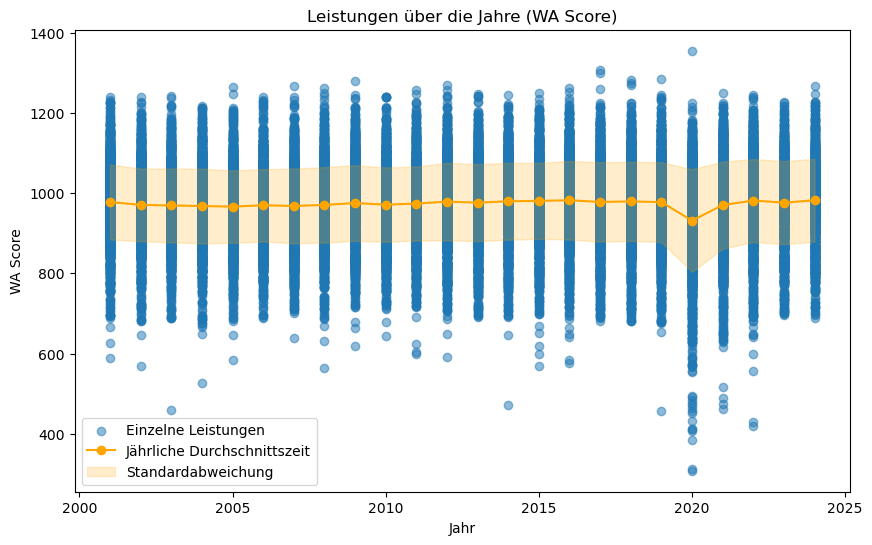

In [17]:

# Plot all data points with times on y-axis and year on x-axis + Mean per year line
mean_per_year = data_wa.groupby("jahr")["wa_score"].mean()
#Plot also stadard deviation as shaded area
std_per_year = data_wa.groupby("jahr")["wa_score"].std()
plt.figure(figsize=(10, 6))
plt.scatter(data_wa["jahr"], data_wa["wa_score"], alpha=0.5, label="Einzelne Leistungen")
plt.plot(mean_per_year.index, mean_per_year.values, color='orange', marker='o', label='Jährliche Durchschnittszeit')
plt.fill_between(
    mean_per_year.index,
    mean_per_year - std_per_year,
    mean_per_year + std_per_year,
    color='orange',
    alpha=0.2,
    label='Standardabweichung'
)
plt.title(f'Leistungen über die Jahre (WA Score)')
plt.xlabel('Jahr')              
plt.ylabel('WA Score')
plt.legend()
plt.show()

In [18]:
data_wa_filtered = data_wa[data_wa["wa_score"] > 1300]

data_wa_filtered

,jahr,geschlecht,altersklasse,disziplin,leistung,wind,name,geburtsjahr,verein,datum,ort,wa_score
133432,2017,M,Erwachsene,Speerwurf,94.44,NaN,Johannes Vetter,1993,LG Offenburg,11.07.,Luzern/SUI,1308.0
193255,2020,M,Erwachsene,Speerwurf,97.76,NaN,Johannes Vetter,1993,LG Offenburg,06.09.2020,Chorzow,1355.0
